In [44]:
import numpy as np 
from pyvista import examples
import pyvista as pv
from pathlib import Path
from matplotlib import rc
import matplotlib.pyplot as plt

In [45]:
def set_rc_params(fontsize=None):
    '''
    Set figure parameters
    '''

    if fontsize is None:
        fontsize = 16
    else:
        fontsize = int(fontsize)

    rc('font', **{'family': 'serif'})
    rc('text', usetex=False)

    plt.rcParams.update({'axes.linewidth': 1.3})
    plt.rcParams.update({'xtick.labelsize': fontsize})
    plt.rcParams.update({'ytick.labelsize': fontsize})
    plt.rcParams.update({'xtick.major.size': 8})
    plt.rcParams.update({'xtick.major.width': 1.3})
    plt.rcParams.update({'xtick.minor.visible': True})
    plt.rcParams.update({'xtick.minor.width': 1.})
    plt.rcParams.update({'xtick.minor.size': 6})
    plt.rcParams.update({'xtick.direction': 'out'})
    plt.rcParams.update({'ytick.major.width': 1.3})
    plt.rcParams.update({'ytick.major.size': 8})
    plt.rcParams.update({'ytick.minor.visible': True})
    plt.rcParams.update({'ytick.minor.width': 1.})
    plt.rcParams.update({'ytick.minor.size': 6})
    plt.rcParams.update({'ytick.direction': 'out'})
    plt.rcParams.update({'axes.labelsize': fontsize})
    plt.rcParams.update({'axes.titlesize': fontsize})
    plt.rcParams.update({'legend.fontsize': int(fontsize-2)})
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'


set_rc_params(15)

### Getting the needed functions from `eval_rollout`

In [3]:
objects = {
    "armadillo": examples.download_armadillo(),
    "urn": examples.download_urn(),
}

In [6]:
decimate_ratio = {
    "armadillo": 0.99,
    "urn": 0.98,
}

In [7]:
def get_mesh(name):
    mesh = objects[name]

    mesh = mesh.decimate(decimate_ratio[name])
    _ = mesh.clean(inplace=True)

    return mesh

In [166]:
def screenshot_mesh(mesh, scalars, name, save_path, clim):
    pl = pv.Plotter(off_screen=True)
    pl.set_background("white")

    mesh.point_data["c"] = scalars
    mesh.set_active_scalars("c")
    
    clim = clim
    pl.add_mesh(mesh, clim=clim, cmap="coolwarm")

    pl.remove_scalar_bar()

    if name == "armadillo":
        pl.camera_position = "xy"
        pl.camera.azimuth = 225
    elif name.startswith("bunny"):
        pl.camera_position = "xy"
    elif name in ["lucy", "sphere"]:
        pl.camera_position = "yz"
        pl.camera.azimuth = 90
    elif name in ["spider"]:
        pl.camera_position = "xy"
        pl.camera.roll = -110
    elif name == "urn":
        pl.camera_position = "xy"
        pl.camera.azimuth = -30
    elif name == "woman":
        pl.camera_position = "yz"
        pl.camera.azimuth = 180
    elif name == "supertoroid":
        pl.camera_position = "xy"
    elif name == "ellipsoid":
        pl.camera_position = "xy"

    img = pl.screenshot(filename=save_path, return_img=True)
    pl.close()
    
    return img

In [162]:
urnmesh = get_mesh("urn")
armadillomesh = get_mesh("armadillo")

### Loading in the .npy files

In [195]:
base_dir = Path("data/armadillo")

eman_predictions = np.load(base_dir / "EMAN" / "predictions.npy")
ground_truth = np.load(base_dir / "EMAN" / "ground_truth.npy")
uni_predictions = np.load(base_dir / "Uni" / "predictions.npy")
hermes_predictions = np.load(base_dir / "Hermes" / "predictions.npy")

time = 190
eman_pred_t100 = eman_predictions[..., 190]
uni_pred_t100 = uni_predictions[..., 190]
hermes_pred_t100 = hermes_predictions[..., 190]
gt_t100 = ground_truth[..., 190]
traj = 2
scalars = [
    gt_t100[traj, :],
    eman_pred_t100[traj, :],
    uni_pred_t100[traj, :],
    hermes_pred_t100[traj, :],
]
titles = [
    "Ground Truth",
    "EMAN",
    "R-UniMesh",
    "Hermes",
]

-0.06756078 0.6393989


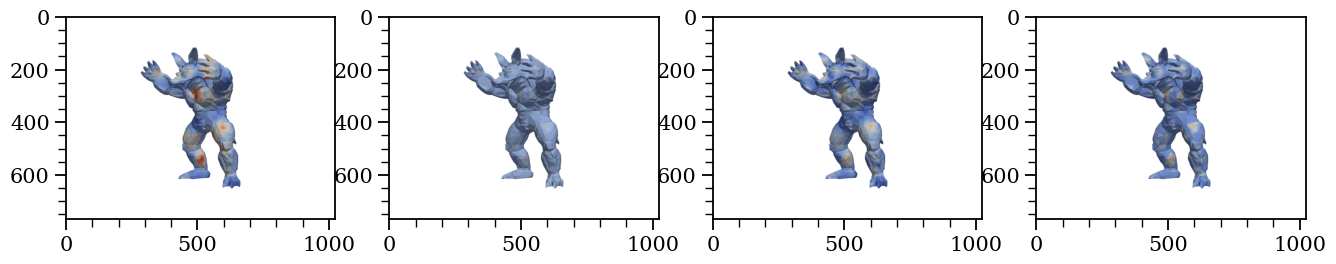

In [201]:
global_min = min(s.min() for s in scalars)
global_max = max(s.max() for s in scalars)
clim = [global_min, global_max]
print(global_min, global_max)

images = [screenshot_mesh(armadillomesh, s, "armadillo", t, clim) for s, t in zip(scalars, titles)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
plt.show()